# 2026-2 COW AI팀 사전 과제 · 1주차
# 탐색적 데이터 분석(EDA) 및 시각화

**주제:** DACON 갑상선암 진단 분류 데이터 (양성/악성 이진 분류)

---

## 목차
- **1-1.** 탐색적 데이터 분석(EDA)이란 무엇이며 왜 수행하는가
- **1-2.** 데이터 분석 및 시각화
- **1-3.** 분석 결과
- **1-4.** 전처리 계획
- **참고 문헌**


---
## 1-1. 탐색적 데이터 분석(EDA)이란 무엇이며 왜 수행하는가

### EDA의 정의
탐색적 데이터 분석(Exploratory Data Analysis, EDA)은 John W. Tukey가 1977년 저서 *Exploratory Data Analysis*
에서 체계화한 접근법으로, **사전에 세운 가설을 검정하기 이전에 데이터 자체가 무엇을 말하는지 그림과 요약통계로
먼저 들어보는 과정**이다. Tukey는 이를 "확증적 분석(Confirmatory Data Analysis)"과 대비시키며,
분석의 출발점은 가설이 아니라 데이터여야 한다고 주장했다.

### EDA의 목적
| 목적 | 구체적 내용 |
|---|---|
| **데이터 이해** | 행/열 규모, 자료형, 각 변수의 의미와 값의 범위를 파악한다 |
| **품질 진단** | 결측치, 중복, 이상치, 논리적으로 불가능한 값을 찾아낸다 |
| **구조 발견** | 변수 간 상관·연관, 그룹별 차이, 상호작용 등 숨은 패턴을 찾는다 |
| **모델링 전략 수립** | 전처리 방법, 파생변수, 알고리즘, 평가지표 선택의 근거를 마련한다 |
| **가설 생성** | 후속 단계에서 검증할 구체적 질문을 만든다 |

### EDA를 수행해야 하는 이유

**1. 전처리와 모델링의 모든 의사결정에 근거를 제공한다.**
"결측치를 평균으로 채운다", "로그 변환을 한다" 같은 선택은 그 자체로 옳고 그름이 없다.
분포가 어떤 모양인지, 결측이 어떤 메커니즘으로 생겼는지 확인한 뒤에야 정당화된다.
EDA 없는 전처리는 관행의 반복일 뿐 근거 있는 설계가 아니다.

**2. Garbage In, Garbage Out을 막는다.**
아무리 정교한 모델도 잘못된 데이터를 바로잡아 주지는 않는다. 중복 행, 라벨 오류, 데이터 누수(leakage)는
모델 성능을 실제보다 부풀리거나 반대로 망가뜨리는데, 이런 문제는 학습 이후가 아니라 EDA 단계에서만
저렴하게 발견된다.

**3. 요약통계만으로는 데이터를 알 수 없기 때문이다.**
Anscombe's Quartet(1973)과 Datasaurus Dozen(2017)은 **평균·분산·상관계수가 완전히 동일하면서도
전혀 다른 모양을 가진 데이터셋**을 제시했다. 숫자만 보고 데이터를 안다고 말할 수 없으며,
반드시 그려 봐야 한다는 것이 EDA의 핵심 논거다.

**4. 단변량 통계는 상호작용을 놓친다.**
개별 변수와 타깃의 상관이 0에 가깝더라도, 두 변수의 **조합**에서는 강한 신호가 존재할 수 있다.
심프슨의 역설(Simpson's Paradox)이 대표적이다. 본 과제의 데이터가 정확히 이 경우에 해당하며,
자세한 내용은 1-3에서 다룬다.

**5. 평가 설계를 좌우한다.**
클래스 불균형 여부를 모른 채 Accuracy를 보면, 아무것도 학습하지 않은 모델이 88%를 기록하는 착시에 빠진다.
어떤 지표를 볼 것인지, 데이터를 어떻게 분할할 것인지는 EDA 결과에서 나온다.


---
## 1-2. 데이터 분석 및 시각화

### 환경 설정 및 데이터 로드

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager as fm
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 60)

# --- 한글 폰트 설정 (환경에 맞는 폰트를 자동 탐색) ---
def set_korean_font():
    candidates = [
        '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',   # Linux
        '/usr/share/fonts/truetype/nanum/NanumGothic.ttf',          # Linux
        '/System/Library/Fonts/AppleSDGothicNeo.ttc',               # macOS
        'C:/Windows/Fonts/malgun.ttf',                              # Windows
    ]
    for path in candidates:
        if os.path.exists(path):
            fm.fontManager.addfont(path)
            name = fm.FontProperties(fname=path).get_name()
            plt.rcParams['font.family'] = name
            return name
    return plt.rcParams['font.family']

FONT = set_korean_font()
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'
sns.set_style('whitegrid', {'font.family': plt.rcParams['font.family']})

FIGDIR = 'figures'
os.makedirs(FIGDIR, exist_ok=True)
print('폰트:', FONT)

폰트: Noto Sans CJK JP


In [2]:
# --- 데이터 로드 ---
# 데이터 파일이 있는 경로로 수정하세요.
DATA_DIR = 'data'

train = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

print(f'train: {train.shape[0]:,} 행 x {train.shape[1]} 열')
print(f'test : {test.shape[0]:,} 행 x {test.shape[1]} 열')
train.head()

train: 87,159 행 x 16 열
test : 46,204 행 x 15 열


,ID,Age,Gender,Country,Race,Family_Background,Radiation_History,Iodine_Deficiency,Smoke,Weight_Risk,Diabetes,Nodule_Size,TSH_Result,T4_Result,T3_Result,Cancer
0,TRAIN_00000,80,M,CHN,ASN,Positive,Exposed,Sufficient,Non-Smoker,Not Obese,No,0.650355,2.784735,6.744603,2.575820,1
1,TRAIN_00001,37,M,NGA,ASN,Positive,Unexposed,Sufficient,Smoker,Obese,No,2.950430,0.911624,7.303305,2.505317,1
2,TRAIN_00002,71,M,CHN,MDE,Positive,Unexposed,Sufficient,Non-Smoker,Not Obese,Yes,2.200023,0.717754,11.137459,2.381080,0
3,TRAIN_00003,40,F,IND,HSP,Negative,Unexposed,Sufficient,Non-Smoker,Obese,No,3.370796,6.846380,10.175254,0.753023,0
4,TRAIN_00004,53,F,CHN,CAU,Negative,Unexposed,Sufficient,Non-Smoker,Not Obese,No,4.230048,0.439519,7.194450,0.569356,1


### (1) 데이터 기본 정보

먼저 자료형, 결측치, 고유값 개수를 한 표로 정리한다.

In [3]:
TARGET = 'Cancer'
ID = 'ID'
NUM_COLS = ['Age', 'Nodule_Size', 'TSH_Result', 'T4_Result', 'T3_Result']
CAT_COLS = ['Gender', 'Country', 'Race', 'Family_Background', 'Radiation_History',
            'Iodine_Deficiency', 'Smoke', 'Weight_Risk', 'Diabetes']

overview = pd.DataFrame({
    '자료형': train.dtypes.astype(str),
    '결측치수': train.isnull().sum(),
    '결측률(%)': (train.isnull().mean() * 100).round(2),
    '고유값수': train.nunique(),
    '예시값': [train[c].iloc[0] for c in train.columns],
})
overview

,자료형,결측치수,결측률(%),고유값수,예시값
ID,object,0,0.0,87159,TRAIN_00000
Age,int64,0,0.0,75,80
Gender,object,0,0.0,2,M
Country,object,0,0.0,10,CHN
Race,object,0,0.0,5,ASN
Family_Background,object,0,0.0,2,Positive
Radiation_History,object,0,0.0,2,Exposed
Iodine_Deficiency,object,0,0.0,2,Sufficient
Smoke,object,0,0.0,2,Non-Smoker
Weight_Risk,object,0,0.0,2,Not Obese


In [4]:
print('■ 결측치 총합 : train =', train.isnull().sum().sum(), '/ test =', test.isnull().sum().sum())
print('■ 완전 중복 행(ID 제외) :', train.drop(columns=[ID]).duplicated().sum())
print('■ ID 중복 :', train[ID].duplicated().sum())
print('■ train/test 컬럼 차이 :', set(train.columns) - set(test.columns))
print()
print('■ 변수 구성')
print(f'  - 식별자 1개    : {ID}')
print(f'  - 수치형 {len(NUM_COLS)}개   : {NUM_COLS}')
print(f'  - 범주형 {len(CAT_COLS)}개   : {CAT_COLS}')
print(f'  - 타깃 1개      : {TARGET}')

■ 결측치 총합 : train = 0 / test = 0


■ 완전 중복 행(ID 제외) : 0
■ ID 중복 : 0
■ train/test 컬럼 차이 : {'Cancer'}

■ 변수 구성
  - 식별자 1개    : ID
  - 수치형 5개   : ['Age', 'Nodule_Size', 'TSH_Result', 'T4_Result', 'T3_Result']
  - 범주형 9개   : ['Gender', 'Country', 'Race', 'Family_Background', 'Radiation_History', 'Iodine_Deficiency', 'Smoke', 'Weight_Risk', 'Diabetes']
  - 타깃 1개      : Cancer


**변수 설명**

| 변수 | 유형 | 의미 |
|---|---|---|
| `Age` | 수치 | 나이 (14~88세) |
| `Gender` | 범주 | 성별 (M / F) |
| `Country` | 범주 | 국가 (10개국) |
| `Race` | 범주 | 인종 (ASN/AFR/CAU/HSP/MDE) |
| `Family_Background` | 범주 | 가족력 (Positive / Negative) |
| `Radiation_History` | 범주 | 방사선 노출 이력 (Exposed / Unexposed) |
| `Iodine_Deficiency` | 범주 | 요오드 결핍 (Deficient / Sufficient) |
| `Smoke` | 범주 | 흡연 여부 |
| `Weight_Risk` | 범주 | 비만 여부 |
| `Diabetes` | 범주 | 당뇨 여부 |
| `Nodule_Size` | 수치 | 결절 크기 |
| `TSH_Result` | 수치 | 갑상선자극호르몬 수치 |
| `T4_Result` | 수치 | 티록신(T4) 수치 |
| `T3_Result` | 수치 | 삼요오드티로닌(T3) 수치 |
| **`Cancer`** | **타깃** | **1 = 악성, 0 = 양성** |

### (2) 클래스(Target) 분포

0 (양성) : 76,700 건  (88.00%)
1 (악성) : 10,459 건  (12.00%)
불균형 비율 : 1 : 7.33

※ 모두 0으로 예측하는 무의미한 모델의 Accuracy = 0.8800


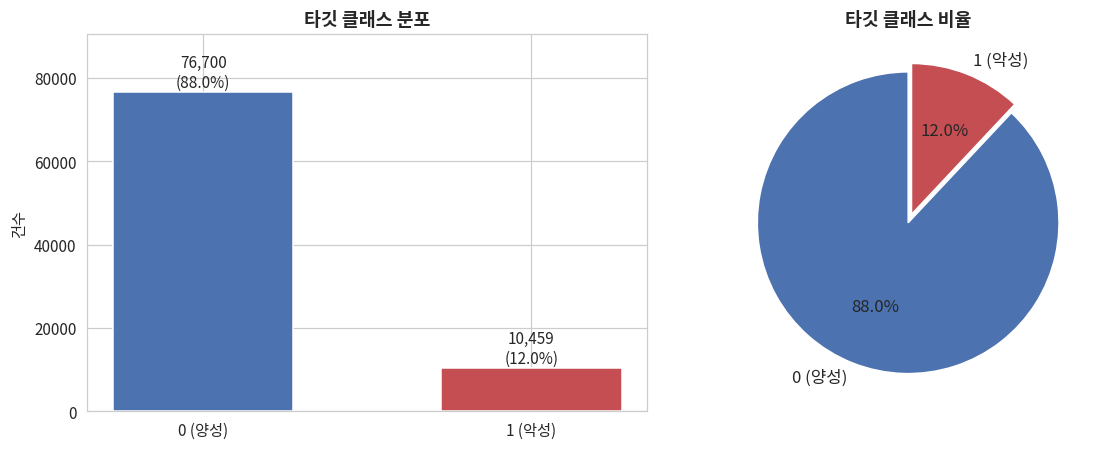

In [5]:
cnt = train[TARGET].value_counts().sort_index()
pct = train[TARGET].value_counts(normalize=True).sort_index() * 100
ratio = cnt[0] / cnt[1]

print(f'0 (양성) : {cnt[0]:,} 건  ({pct[0]:.2f}%)')
print(f'1 (악성) : {cnt[1]:,} 건  ({pct[1]:.2f}%)')
print(f'불균형 비율 : 1 : {ratio:.2f}')
print(f'\n※ 모두 0으로 예측하는 무의미한 모델의 Accuracy = {pct[0]/100:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
bars = axes[0].bar(['0 (양성)', '1 (악성)'], cnt.values,
                   color=['#4C72B0', '#C44E52'], width=0.55)
for b, v, p in zip(bars, cnt.values, pct.values):
    axes[0].text(b.get_x() + b.get_width()/2, v + 1200, f'{v:,}\n({p:.1f}%)',
                 ha='center', fontsize=10)
axes[0].set_ylim(0, cnt.max() * 1.18)
axes[0].set_ylabel('건수')
axes[0].set_title('타깃 클래스 분포', fontsize=12, fontweight='bold')

axes[1].pie(cnt.values, labels=['0 (양성)', '1 (악성)'], autopct='%1.1f%%',
            colors=['#4C72B0', '#C44E52'], startangle=90,
            explode=(0, 0.06), textprops={'fontsize': 11})
axes[1].set_title('타깃 클래스 비율', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig01_target.png')
plt.show()

> **약 12%만이 악성인 불균형 데이터**다. 8:1에 가까운 비율이므로,
> Accuracy를 주지표로 삼으면 안 되며 F1-score·Recall·PR-AUC를 함께 봐야 한다.
> (실제로 이 데이터를 사용한 DACON 해커톤의 공식 평가지표도 F1 Score이다.)

### (3) 각 컬럼의 데이터 분포 — 수치형

In [6]:
desc = train[NUM_COLS].describe().T
desc['skew'] = train[NUM_COLS].skew()
desc['kurtosis'] = train[NUM_COLS].kurt()
desc.round(4)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
Age,87159.0,50.8602,21.6387,14.0,32.0000,51.0000,70.0000,88.0,0.0058,-1.1987
Nodule_Size,87159.0,2.5081,1.4419,0.0,1.2703,2.5209,3.7609,5.0,-0.0070,-1.1967
TSH_Result,87159.0,5.0569,2.8612,0.1,2.5828,5.0591,7.5416,10.0,-0.0004,-1.2013
T4_Result,87159.0,8.2488,2.1660,4.5,6.3720,8.2368,10.1270,12.0,0.0024,-1.2021
T3_Result,87159.0,2.0050,0.8670,0.5,1.2548,2.0041,2.7580,3.5,-0.0001,-1.2031


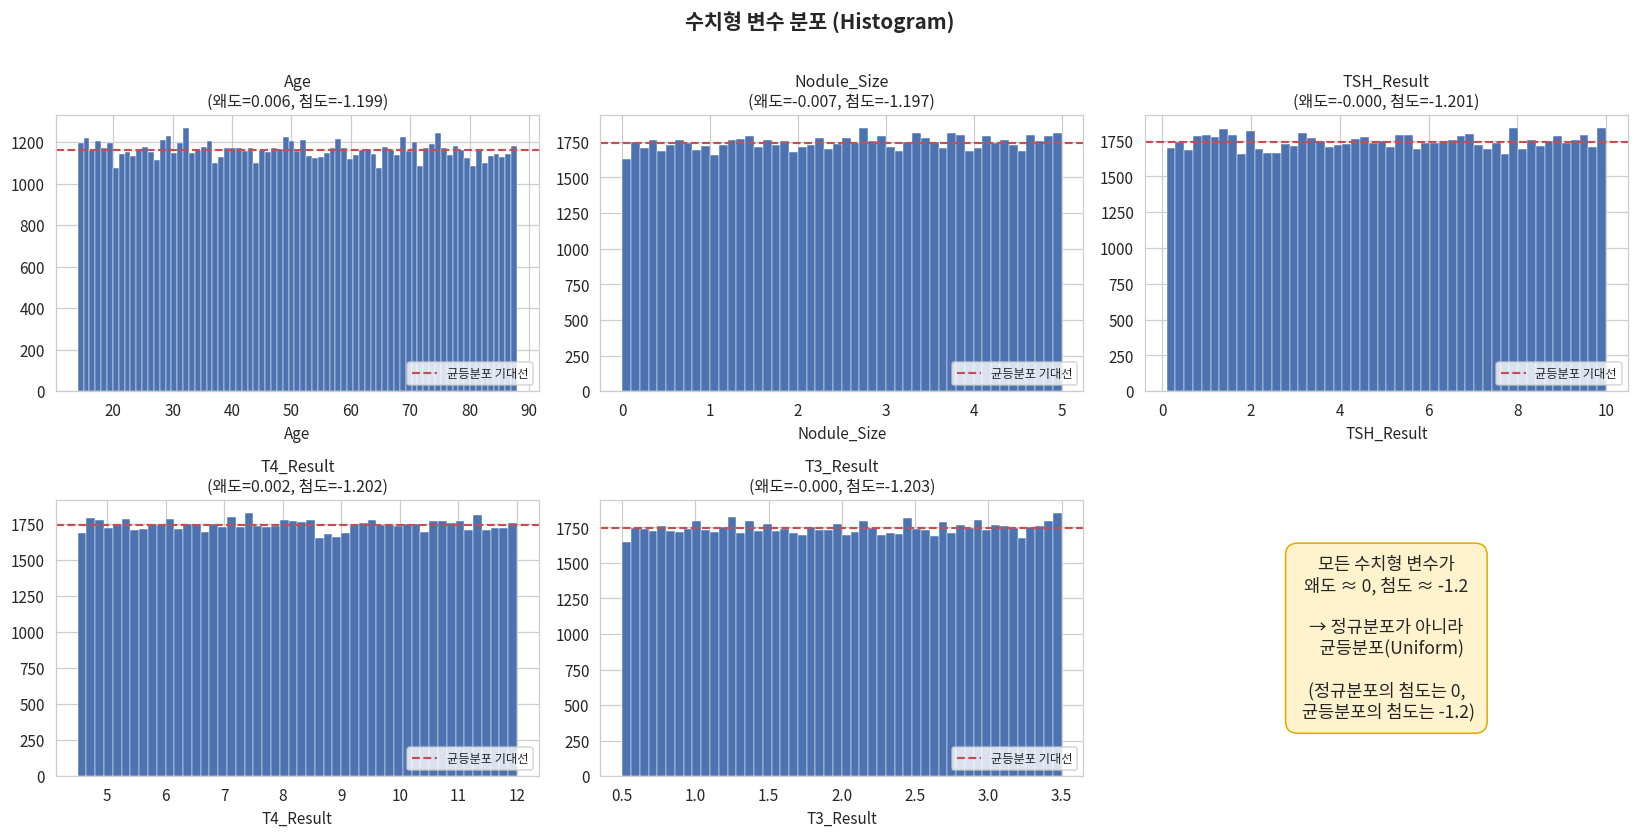

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
axes = axes.ravel()
for i, c in enumerate(NUM_COLS):
    # Age는 정수형(75개 값)이므로 구간 수를 값 개수에 맞춰야 빗살 무늬가 생기지 않는다
    nb_bins = train[c].nunique() if train[c].nunique() <= 100 else 50
    axes[i].hist(train[c], bins=nb_bins, color='#4C72B0', edgecolor='white', linewidth=0.3)
    axes[i].axhline(len(train)/nb_bins, color='#C44E52', ls='--', lw=1.4,
                    label='균등분포 기대선')
    axes[i].set_title(f'{c}\n(왜도={train[c].skew():.3f}, 첨도={train[c].kurt():.3f})',
                      fontsize=10.5)
    axes[i].set_xlabel(c)
    axes[i].legend(fontsize=8, loc='lower right')
axes[-1].axis('off')
axes[-1].text(0.5, 0.5,
              '모든 수치형 변수가\n왜도 ≈ 0, 첨도 ≈ -1.2\n\n→ 정규분포가 아니라\n   균등분포(Uniform)\n\n(정규분포의 첨도는 0,\n 균등분포의 첨도는 -1.2)',
              ha='center', va='center', fontsize=11.5,
              bbox=dict(boxstyle='round,pad=0.7', fc='#FFF3CD', ec='#E0A800'))
plt.suptitle('수치형 변수 분포 (Histogram)', fontsize=13.5, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig02_numeric_hist.png')
plt.show()

> 다섯 개 수치형 변수 모두 **왜도 ≈ 0, 첨도 ≈ -1.2**로, 이는 균등분포의 이론적 첨도값(-1.2)과 일치한다.
> 즉 실제 임상 데이터의 자연스러운 분포(TSH는 통상 로그정규 형태)가 아니라, **정해진 구간에서
> 균일하게 생성된 합성 데이터(synthetic data)**임을 시사한다. 이 관찰은 뒤이은 이상치 판단과
> 스케일링 전략에 직접적인 영향을 준다.

### (4) 각 컬럼의 데이터 분포 — 범주형

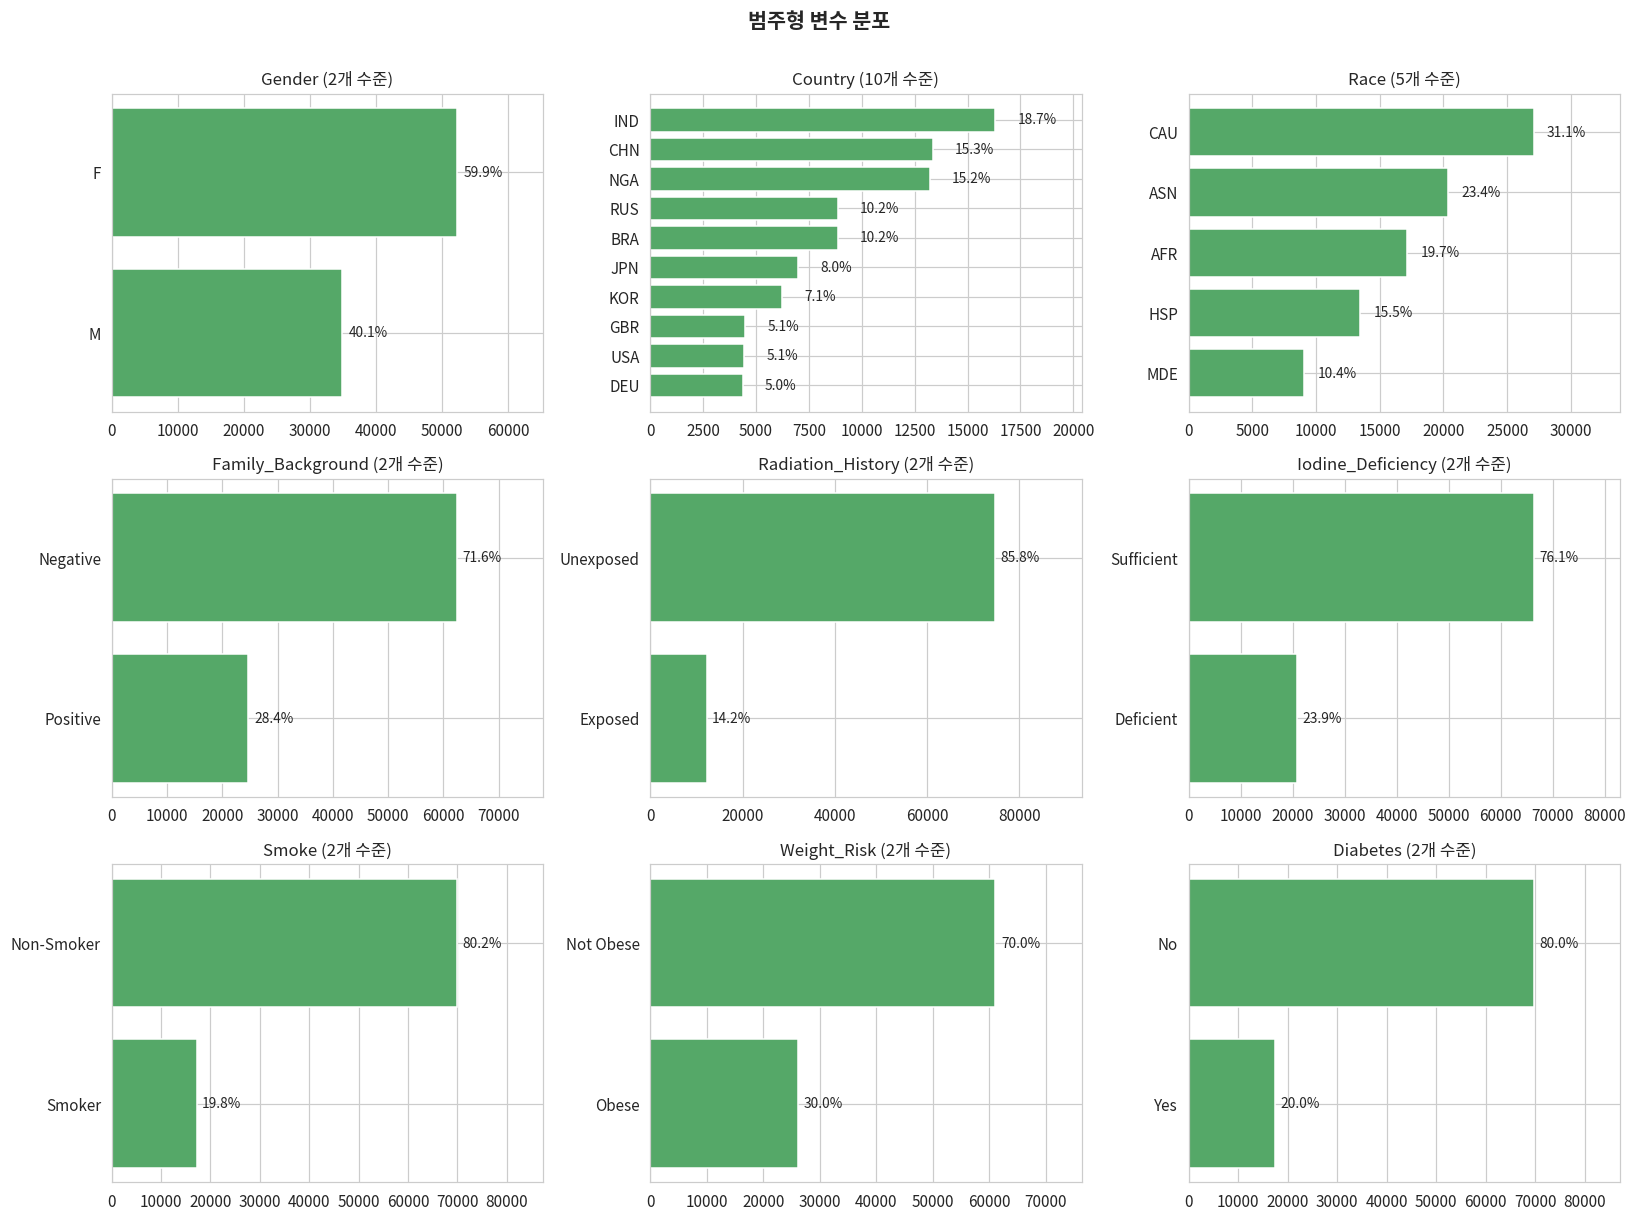

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.ravel()
for i, c in enumerate(CAT_COLS):
    vc = train[c].value_counts()
    axes[i].barh(vc.index.astype(str)[::-1], vc.values[::-1], color='#55A868')
    for y, v in enumerate(vc.values[::-1]):
        axes[i].text(v + len(train)*0.012, y, f'{v/len(train)*100:.1f}%',
                     va='center', fontsize=9)
    axes[i].set_xlim(0, vc.max() * 1.25)
    axes[i].set_title(f'{c} ({train[c].nunique()}개 수준)', fontsize=11)
plt.suptitle('범주형 변수 분포', fontsize=13.5, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig03_categorical_dist.png')
plt.show()

### (5) 변수 간 상관관계

수치형 변수는 Pearson 상관계수로, 범주형 변수는 카이제곱 검정 기반의 **Cramér's V**로 측정한다.
(Cramér's V는 0~1 범위이며, 명목형 변수 간 연관 강도를 나타낸다.)

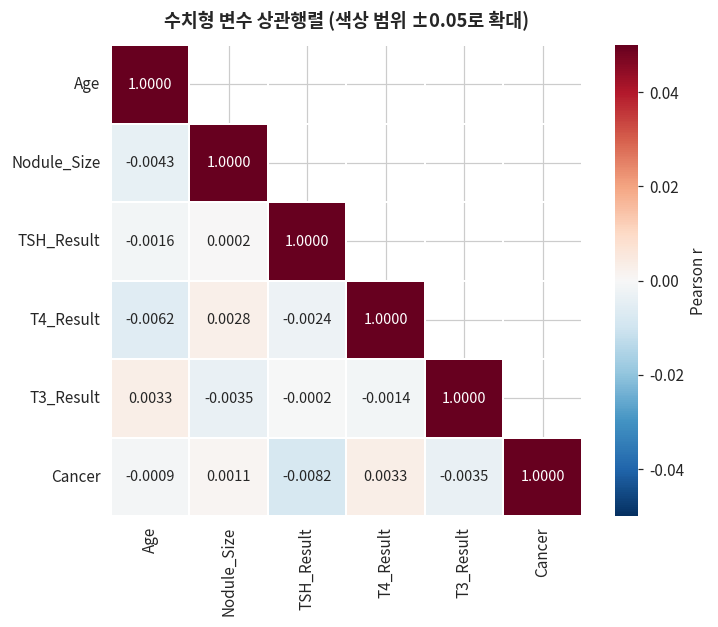

타깃과의 상관계수 절댓값 최대 : 0.00822


In [9]:
corr = train[NUM_COLS + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(7.2, 5.8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.4f', cmap='RdBu_r',
            center=0, vmin=-0.05, vmax=0.05, square=True,
            linewidths=1, cbar_kws={'label': 'Pearson r'}, ax=ax,
            annot_kws={'fontsize': 9.5})
ax.set_title('수치형 변수 상관행렬 (색상 범위 ±0.05로 확대)',
             fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig04_correlation.png')
plt.show()

print('타깃과의 상관계수 절댓값 최대 :',
      corr[TARGET].drop(TARGET).abs().max().round(5))

> **주의:** 색상 범위를 ±0.05로 확대하지 않으면 모든 칸이 흰색으로만 보인다.
> 실제 상관계수의 절댓값이 전부 0.01 미만이기 때문이다. 시각화 시 스케일을 조정해야
> "상관이 없다"는 사실 자체를 확인할 수 있다.

In [10]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(ct)[0]
    n = ct.values.sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

rows = []
for c in CAT_COLS:
    ct = pd.crosstab(train[c], train[TARGET])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    rows.append({'변수': c, 'chi2': chi2, 'p-value': p,
                 "Cramér's V": cramers_v(train[c], train[TARGET])})
for c in NUM_COLS:
    r, p = stats.pointbiserialr(train[TARGET], train[c])
    rows.append({'변수': c, 'chi2': np.nan, 'p-value': p, "Cramér's V": abs(r)})

assoc = pd.DataFrame(rows).sort_values("Cramér's V", ascending=False).reset_index(drop=True)
assoc['유형'] = np.where(assoc['변수'].isin(CAT_COLS), '범주형 (Cramér\'s V)', '수치형 (|점이연 상관|)')
assoc['유의성'] = np.where(assoc['p-value'] < 0.001, '***',
                  np.where(assoc['p-value'] < 0.01, '**',
                  np.where(assoc['p-value'] < 0.05, '*', 'n.s.')))
assoc.round(6)

,변수,chi2,p-value,Cramér's V,유형,유의성
0,Race,1384.239407,0.000000,0.126023,범주형 (Cramér's V),***
1,Family_Background,1000.577205,0.000000,0.107144,범주형 (Cramér's V),***
2,Country,801.679379,0.000000,0.095906,범주형 (Cramér's V),***
3,Iodine_Deficiency,556.356853,0.000000,0.079895,범주형 (Cramér's V),***
4,Radiation_History,488.617923,0.000000,0.074874,범주형 (Cramér's V),***
5,TSH_Result,NaN,0.015220,0.008221,수치형 (|점이연 상관|),*
6,T3_Result,NaN,0.296946,0.003533,수치형 (|점이연 상관|),n.s.
7,T4_Result,NaN,0.329497,0.003303,수치형 (|점이연 상관|),n.s.
8,Weight_Risk,0.435488,0.509308,0.002235,범주형 (Cramér's V),n.s.
9,Nodule_Size,NaN,0.751202,0.001074,수치형 (|점이연 상관|),n.s.


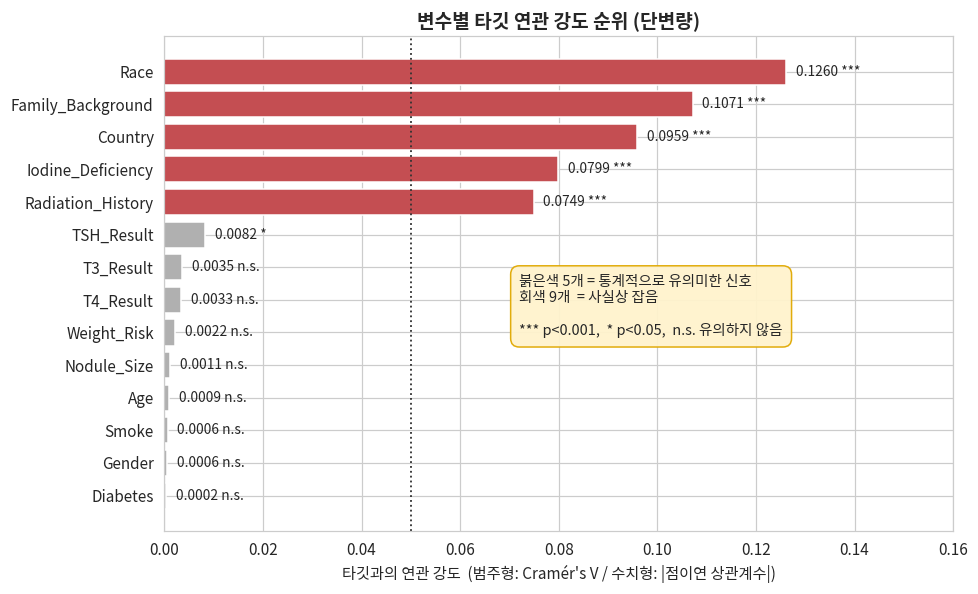

In [11]:
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = ['#C44E52' if v >= 0.05 else '#B0B0B0' for v in assoc["Cramér's V"]]
bars = ax.barh(assoc['변수'][::-1], assoc["Cramér's V"][::-1], color=colors[::-1])
for y, (v, s) in enumerate(zip(assoc["Cramér's V"][::-1], assoc['유의성'][::-1])):
    ax.text(v + 0.002, y, f'{v:.4f} {s}', va='center', fontsize=9)
ax.axvline(0.05, color='#333', ls=':', lw=1.2)
ax.set_xlim(0, 0.16)
ax.set_xlabel("타깃과의 연관 강도  (범주형: Cramér's V / 수치형: |점이연 상관계수|)")
ax.set_title('변수별 타깃 연관 강도 순위 (단변량)', fontsize=12.5, fontweight='bold')
ax.text(0.072, 5.8,
        '붉은색 5개 = 통계적으로 유의미한 신호\n회색 9개  = 사실상 잡음\n\n*** p<0.001,  * p<0.05,  n.s. 유의하지 않음',
        fontsize=9.5, va='center',
        bbox=dict(boxstyle='round,pad=0.6', fc='#FFF3CD', ec='#E0A800', alpha=0.95))
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig05_association.png')
plt.show()

> 단변량 기준으로 **`Race`, `Family_Background`, `Country`, `Iodine_Deficiency`, `Radiation_History`**
> 5개만 통계적으로 유의하다. `Gender`, `Smoke`, `Weight_Risk`, `Diabetes`는 p-value가 0.5를 크게 넘어
> 타깃과 아무런 연관이 없고, 수치형 5개도 모두 |r| < 0.01 수준이다.
>
> `TSH_Result`가 p=0.015로 형식상 유의하게 나오지만 상관계수는 -0.008에 불과하다.
> 이는 표본이 87,159건으로 매우 크기 때문에 발생하는 현상으로, **통계적 유의성과
> 실질적 효과 크기는 다르다**는 점을 보여주는 사례다. 실무적으로는 신호가 없다고 봐야 한다.

### (6) 주요 변수별 시각화 — 타깃에 따른 분포 비교 (Boxplot)

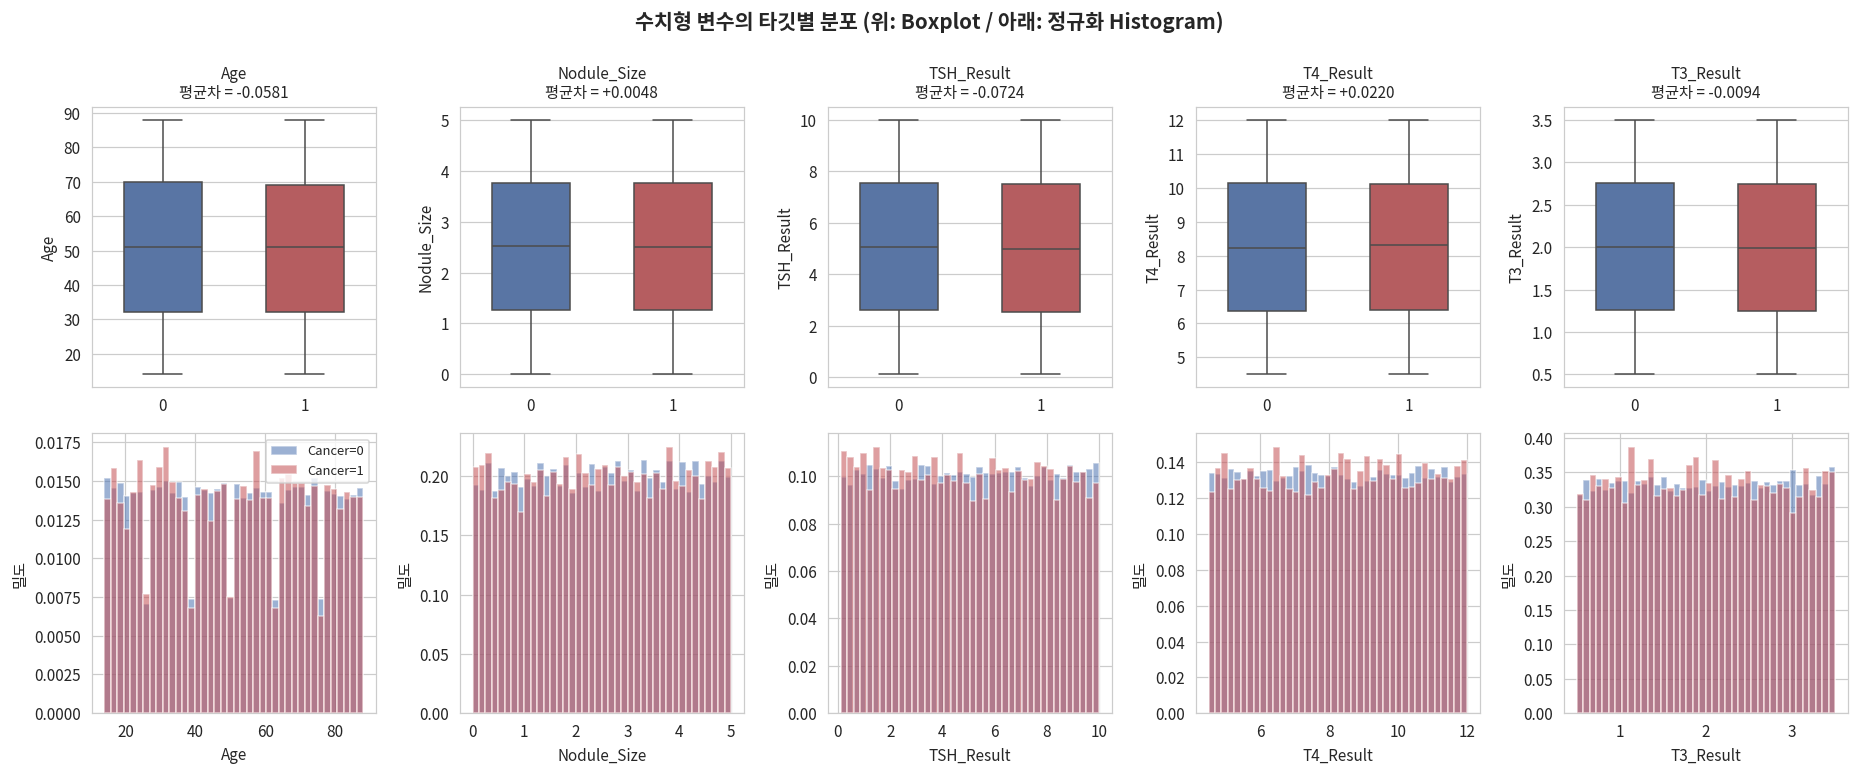

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(17, 7))
for i, c in enumerate(NUM_COLS):
    sns.boxplot(data=train, x=TARGET, y=c, ax=axes[0, i],
                palette=['#4C72B0', '#C44E52'], width=0.55)
    m0, m1 = train.groupby(TARGET)[c].mean()
    axes[0, i].set_title(f'{c}\n평균차 = {m1-m0:+.4f}', fontsize=10)
    axes[0, i].set_xlabel('')

    for t, col in zip([0, 1], ['#4C72B0', '#C44E52']):
        axes[1, i].hist(train.loc[train[TARGET] == t, c], bins=40, density=True,
                        alpha=0.55, color=col, label=f'Cancer={t}')
    axes[1, i].set_xlabel(c)
    axes[1, i].set_ylabel('밀도')
    if i == 0:
        axes[1, i].legend(fontsize=8.5)
plt.suptitle('수치형 변수의 타깃별 분포 (위: Boxplot / 아래: 정규화 Histogram)',
             fontsize=13.5, fontweight='bold', y=1.0)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig06_numeric_boxplot.png')
plt.show()

> 두 클래스의 상자와 밀도곡선이 사실상 완전히 겹친다.
> **수치형 변수만으로는 양성과 악성을 구분할 수 없다.**

In [13]:
# 이상치 점검 (IQR 방식)
rows = []
for c in NUM_COLS:
    q1, q3 = train[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    m = (train[c] < lo) | (train[c] > hi)
    rows.append({'변수': c, '실제최소': train[c].min(), '실제최대': train[c].max(),
                 'IQR하한': lo, 'IQR상한': hi,
                 '이상치수': int(m.sum()), '이상치비율(%)': round(m.mean()*100, 3)})
pd.DataFrame(rows).round(3)

,변수,실제최소,실제최대,IQR하한,IQR상한,이상치수,이상치비율(%)
0,Age,14.0,88.0,-25.000,127.000,0,0.0
1,Nodule_Size,0.0,5.0,-2.466,7.497,0,0.0
2,TSH_Result,0.1,10.0,-4.855,14.980,0,0.0
3,T4_Result,4.5,12.0,0.740,15.759,0,0.0
4,T3_Result,0.5,3.5,-1.000,5.013,0,0.0


> IQR 기준 이상치가 **단 한 건도 없다.** 모든 변수가 명확한 상·하한 안에 균등하게 분포하기 때문이다.
> 또한 `Age`는 14~88세, `Nodule_Size`는 0~5, `TSH`는 0.1~10 등 **의학적으로 불가능한 값도 없다.**

### (7) 범주형 변수별 암 발생률

각 범주 수준에서 실제로 악성 비율이 어떻게 달라지는지 확인한다.
가로 점선은 전체 평균(12.0%)이다.

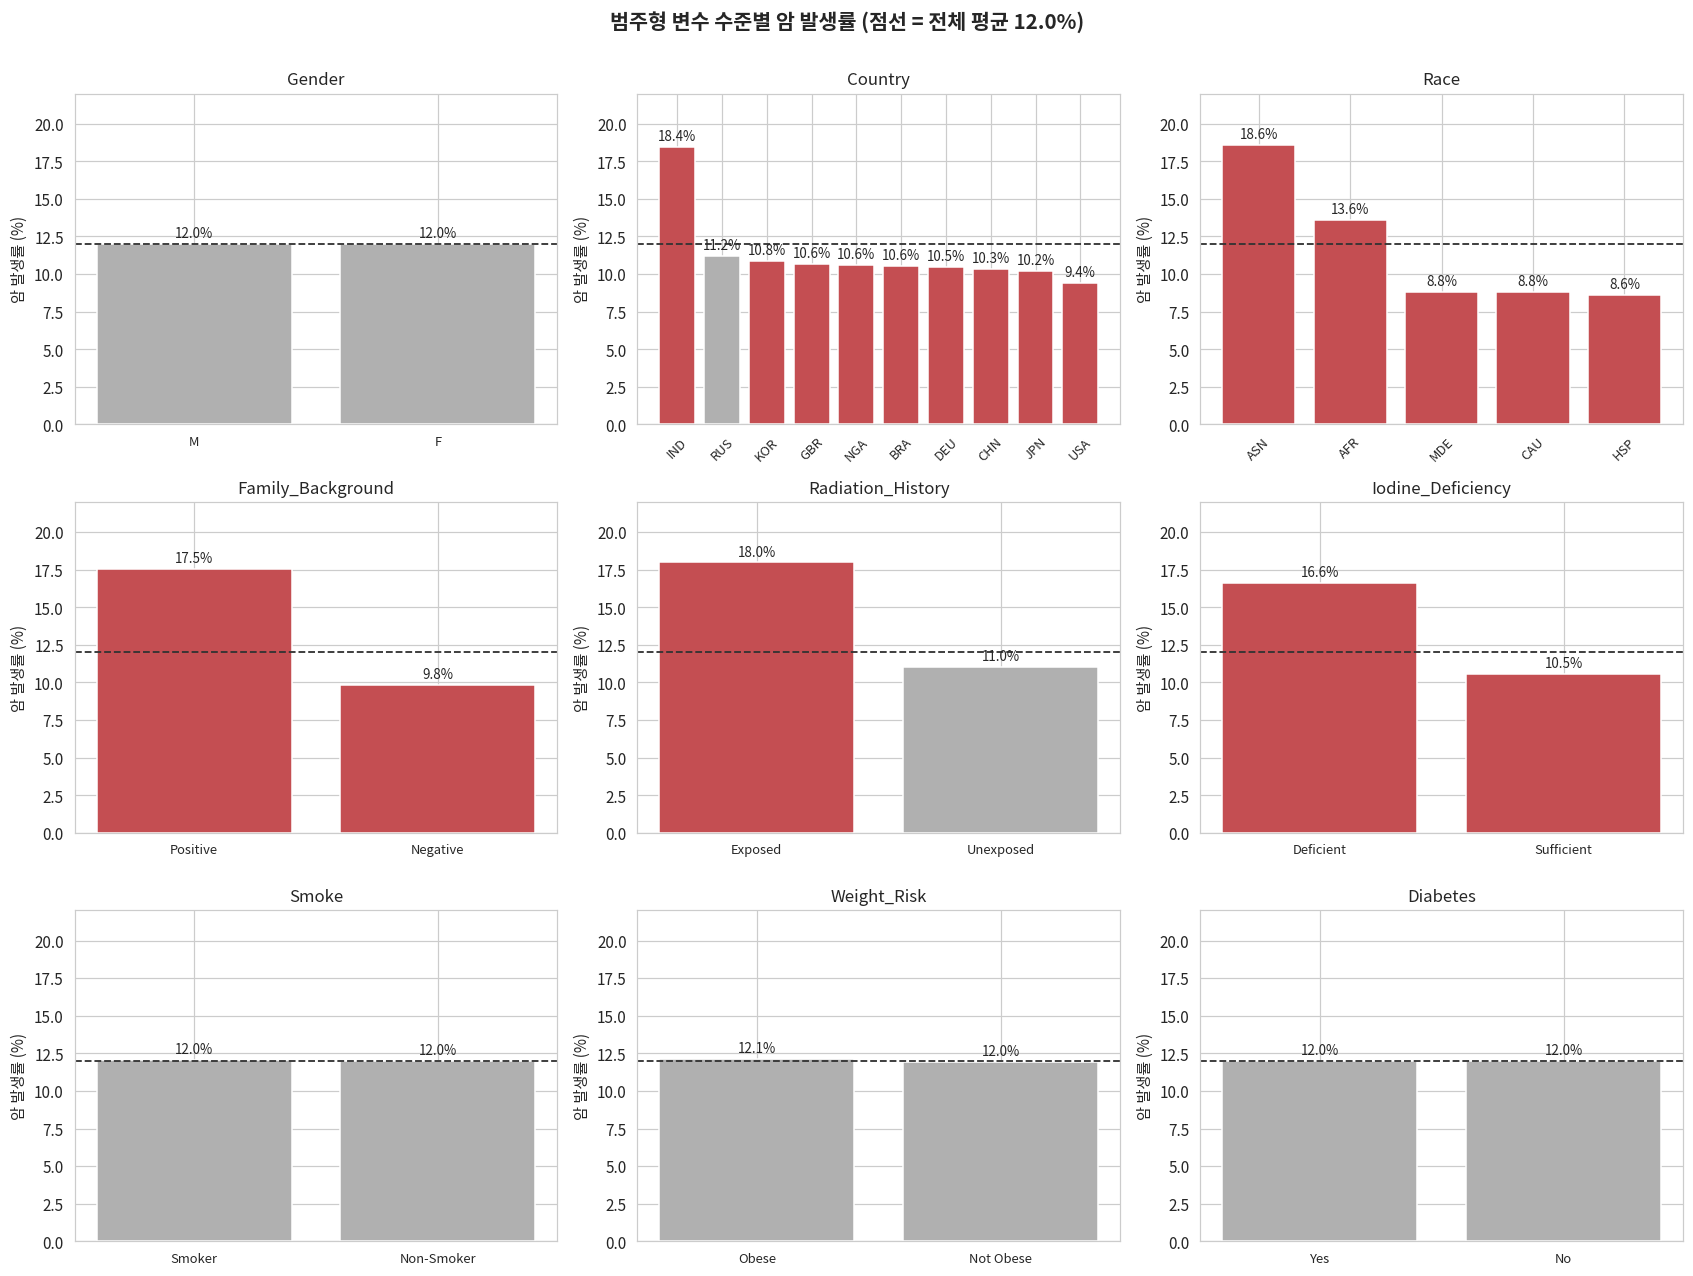

In [14]:
base_rate = train[TARGET].mean()

fig, axes = plt.subplots(3, 3, figsize=(15.5, 11.5))
axes = axes.ravel()
for i, c in enumerate(CAT_COLS):
    g = train.groupby(c)[TARGET].agg(['mean', 'size']).sort_values('mean', ascending=False)
    colors = ['#C44E52' if abs(v - base_rate) > 0.01 else '#B0B0B0' for v in g['mean']]
    axes[i].bar(g.index.astype(str), g['mean']*100, color=colors)
    for x, (v, n) in enumerate(zip(g['mean'], g['size'])):
        axes[i].text(x, v*100 + 0.45, f'{v*100:.1f}%', ha='center', fontsize=8.8)
    axes[i].axhline(base_rate*100, color='#333', ls='--', lw=1.2)
    axes[i].set_ylim(0, 22)
    axes[i].set_ylabel('암 발생률 (%)')
    axes[i].set_title(c, fontsize=11)
    axes[i].tick_params(axis='x', rotation=45 if train[c].nunique() > 4 else 0,
                        labelsize=8.5)
plt.suptitle('범주형 변수 수준별 암 발생률 (점선 = 전체 평균 12.0%)',
             fontsize=13.5, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig07_categorical_rate.png')
plt.show()

> `Gender`, `Smoke`, `Weight_Risk`, `Diabetes`는 모든 수준이 12.0% 선에 붙어 있다(회색).
> 반면 `Race`(ASN 18.6% vs HSP 8.6%), `Family_Background`(17.5% vs 9.8%),
> `Country`(IND 18.5% vs USA 9.4%) 등은 뚜렷한 차이를 보인다.

### (8) 핵심 분석 — 단변량 분석이 놓친 상호작용 구조

여기까지의 결과는 "몇몇 범주형 변수에 약한 신호가 있다" 정도다.
그런데 Cramér's V의 최댓값이 0.126에 불과하다는 점이 이상하다. 신호가 정말 이 정도로 약한 것일까?

**변수를 하나씩 보는 대신 조합해서 보면 완전히 다른 그림이 나타난다.**

In [15]:
# Race x 각 위험요인의 조건부 암 발생률
risk_map = {'Family_Background': 'Positive',
            'Radiation_History': 'Exposed',
            'Iodine_Deficiency': 'Deficient'}

rows = []
for r in sorted(train['Race'].unique()):
    s = train[train['Race'] == r]
    d = {'Race': r, 'n': len(s), '전체발생률(%)': s[TARGET].mean()*100}
    for c, pos in risk_map.items():
        hi = s.loc[s[c] == pos, TARGET].mean()*100
        lo = s.loc[s[c] != pos, TARGET].mean()*100
        d[f'{c}\n(위험군%)'] = hi
        d[f'{c}\n(격차%p)'] = hi - lo
    rows.append(d)
race_tbl = pd.DataFrame(rows)
race_tbl.round(2)

,Race,n,전체발생률(%),Family_Background\n(위험군%),Family_Background\n(격차%p),Radiation_History\n(위험군%),Radiation_History\n(격차%p),Iodine_Deficiency\n(위험군%),Iodine_Deficiency\n(격차%p)
0,AFR,17155,13.62,12.85,-1.09,52.49,43.79,18.05,5.79
1,ASN,20363,18.60,51.31,42.34,18.74,0.16,21.94,4.41
2,CAU,27090,8.78,8.80,0.03,8.63,-0.17,14.02,6.88
3,HSP,13471,8.60,8.64,0.05,8.90,0.35,13.71,6.69
4,MDE,9080,8.79,8.47,-0.45,9.06,0.32,14.08,6.97


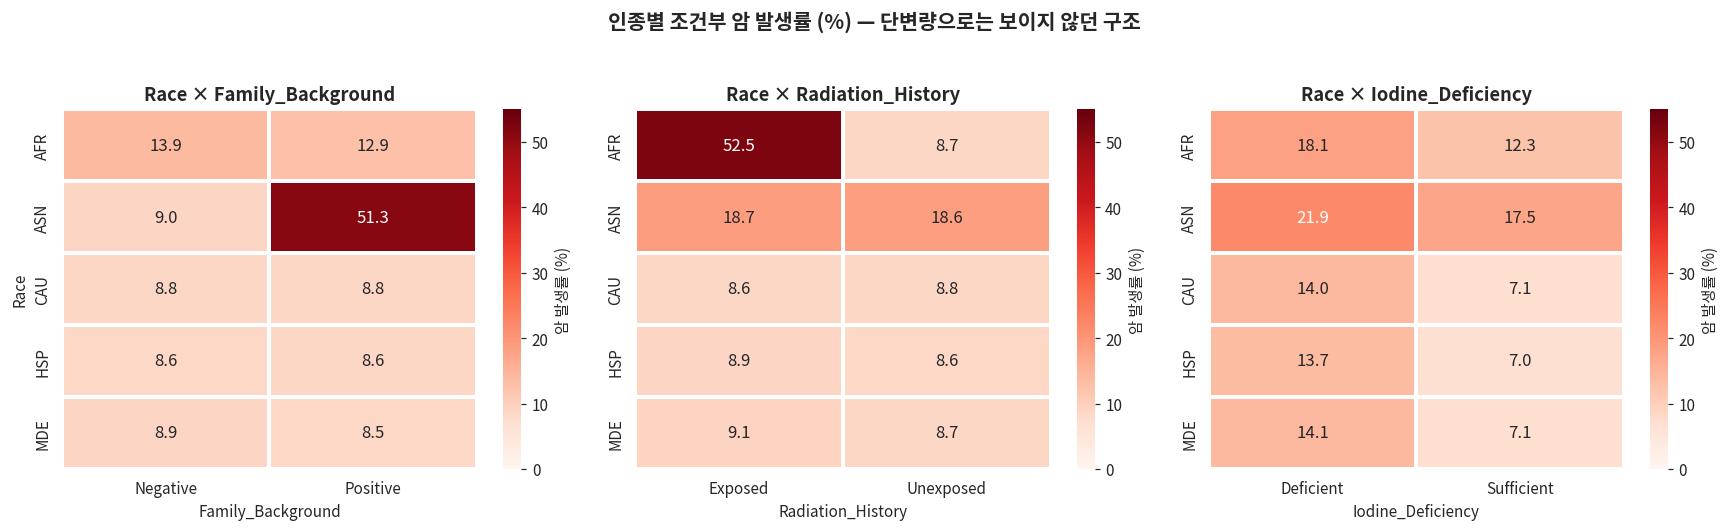

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for i, (c, pos) in enumerate(risk_map.items()):
    piv = train.pivot_table(index='Race', columns=c, values=TARGET, aggfunc='mean') * 100
    sns.heatmap(piv, annot=True, fmt='.1f', cmap='Reds', vmin=0, vmax=55,
                linewidths=1.5, ax=axes[i],
                cbar_kws={'label': '암 발생률 (%)'}, annot_kws={'fontsize': 11})
    axes[i].set_title(f'Race × {c}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Race' if i == 0 else '')
plt.suptitle('인종별 조건부 암 발생률 (%) — 단변량으로는 보이지 않던 구조',
             fontsize=13.5, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig08_interaction_race.png')
plt.show()

> **결정적인 발견이다.**
> - `Race = ASN`일 때만 `Family_Background`가 작동한다 → Positive 51.3% vs Negative 9.0% (격차 **42.3%p**)
> - `Race = AFR`일 때만 `Radiation_History`가 작동한다 → Exposed 52.5% vs Unexposed 8.7% (격차 **43.8%p**)
> - `CAU`, `HSP`, `MDE`는 어떤 요인에도 반응하지 않고 8.6~8.8%에 고정되어 있다.
>
> 전체 데이터에서 `Family_Background`의 효과가 17.5% vs 9.8%(약 7.7%p)로 약해 보였던 이유는,
> **실제 42%p짜리 효과가 ASN이 아닌 76.6%의 표본에 희석되었기 때문**이다.
> 이것이 앞서 언급한 심프슨의 역설이 작동하는 방식이다.

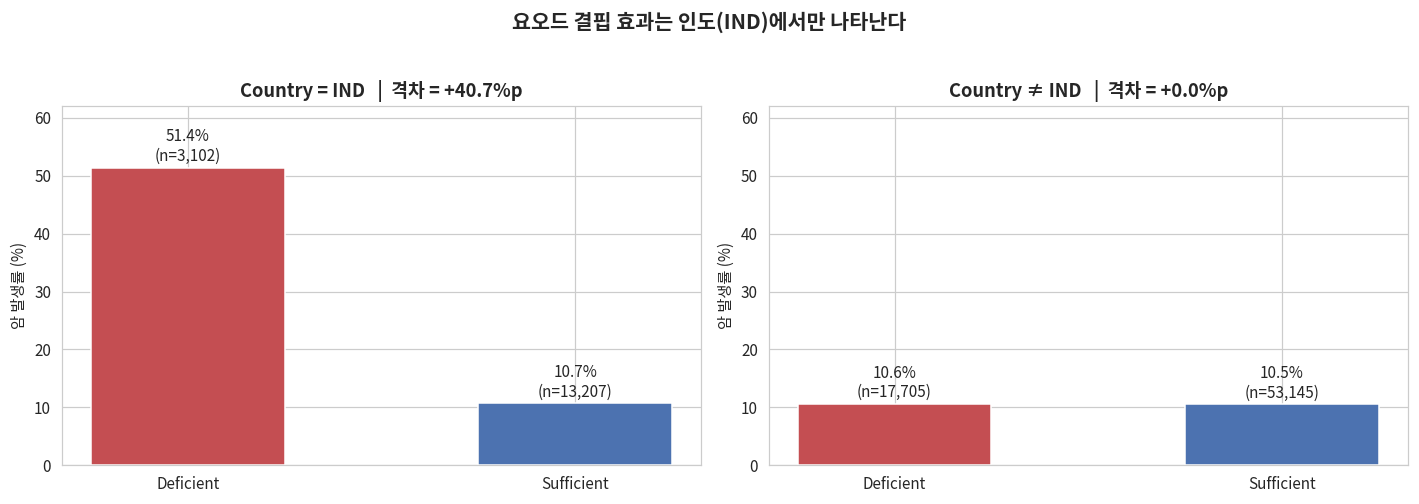

In [17]:
# Country=IND 에서만 나타나는 Iodine_Deficiency 효과
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, (lab, s) in zip(axes, [('Country = IND', train[train['Country'] == 'IND']),
                               ('Country ≠ IND', train[train['Country'] != 'IND'])]):
    g = s.groupby('Iodine_Deficiency')[TARGET].agg(['mean', 'size'])
    bars = ax.bar(g.index, g['mean']*100, color=['#C44E52', '#4C72B0'], width=0.5)
    for b, v, n in zip(bars, g['mean'], g['size']):
        ax.text(b.get_x()+b.get_width()/2, v*100+1.2,
                f'{v*100:.1f}%\n(n={n:,})', ha='center', fontsize=10)
    ax.set_ylim(0, 62)
    ax.set_ylabel('암 발생률 (%)')
    ax.set_title(f'{lab}   |  격차 = {(g["mean"].iloc[0]-g["mean"].iloc[1])*100:+.1f}%p',
                 fontsize=12, fontweight='bold')
plt.suptitle('요오드 결핍 효과는 인도(IND)에서만 나타난다',
             fontsize=13.5, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig09_interaction_ind.png')
plt.show()

> 동일한 패턴이 `Country`에서도 반복된다. `Iodine_Deficiency`는 인도에서만 51.4% vs 10.7%의
> 격차를 만들고, 나머지 9개국에서는 10.55% vs 10.50%로 **차이가 사실상 0이다.**

### (9) 발견한 구조의 검증 — 규칙 기반 재현

세 개의 조건부 규칙만으로 타깃을 얼마나 설명할 수 있는지 정량적으로 확인한다.

In [18]:
def add_rules(df):
    df = df.copy()
    df['R1_ASN_Family'] = ((df['Race'] == 'ASN') &
                           (df['Family_Background'] == 'Positive')).astype(int)
    df['R2_AFR_Radiation'] = ((df['Race'] == 'AFR') &
                              (df['Radiation_History'] == 'Exposed')).astype(int)
    df['R3_IND_Iodine'] = ((df['Country'] == 'IND') &
                           (df['Iodine_Deficiency'] == 'Deficient')).astype(int)
    df['n_rule'] = df[['R1_ASN_Family', 'R2_AFR_Radiation', 'R3_IND_Iodine']].sum(axis=1)
    return df

tr_r = add_rules(train)

rule_summary = []
for name in ['R1_ASN_Family', 'R2_AFR_Radiation', 'R3_IND_Iodine']:
    sub = tr_r[tr_r[name] == 1]
    rule_summary.append({
        '규칙': name,
        '해당 건수': len(sub),
        '전체 대비(%)': len(sub)/len(tr_r)*100,
        '암 발생률(%)': sub[TARGET].mean()*100,
        '전체 양성 중 비중(%)': sub[TARGET].sum()/tr_r[TARGET].sum()*100,
    })
base = tr_r[tr_r['n_rule'] == 0]
rule_summary.append({'규칙': '해당 없음 (기저)', '해당 건수': len(base),
                     '전체 대비(%)': len(base)/len(tr_r)*100,
                     '암 발생률(%)': base[TARGET].mean()*100,
                     '전체 양성 중 비중(%)': base[TARGET].sum()/tr_r[TARGET].sum()*100})
pd.DataFrame(rule_summary).round(2)

,규칙,해당 건수,전체 대비(%),암 발생률(%),전체 양성 중 비중(%)
0,R1_ASN_Family,4631,5.31,51.31,22.72
1,R2_AFR_Radiation,1928,2.21,52.49,9.68
2,R3_IND_Iodine,3102,3.56,51.39,15.24
3,해당 없음 (기저),77826,89.29,7.25,53.92


■ 규칙 3개만으로 예측했을 때 (학습 데이터 기준)
  Accuracy  = 0.8835
  Precision = 0.5163
  Recall    = 0.4608
  F1-score  = 0.4870

■ 비교: 모두 0으로 예측 → Accuracy = 0.8800, F1 = 0.0000


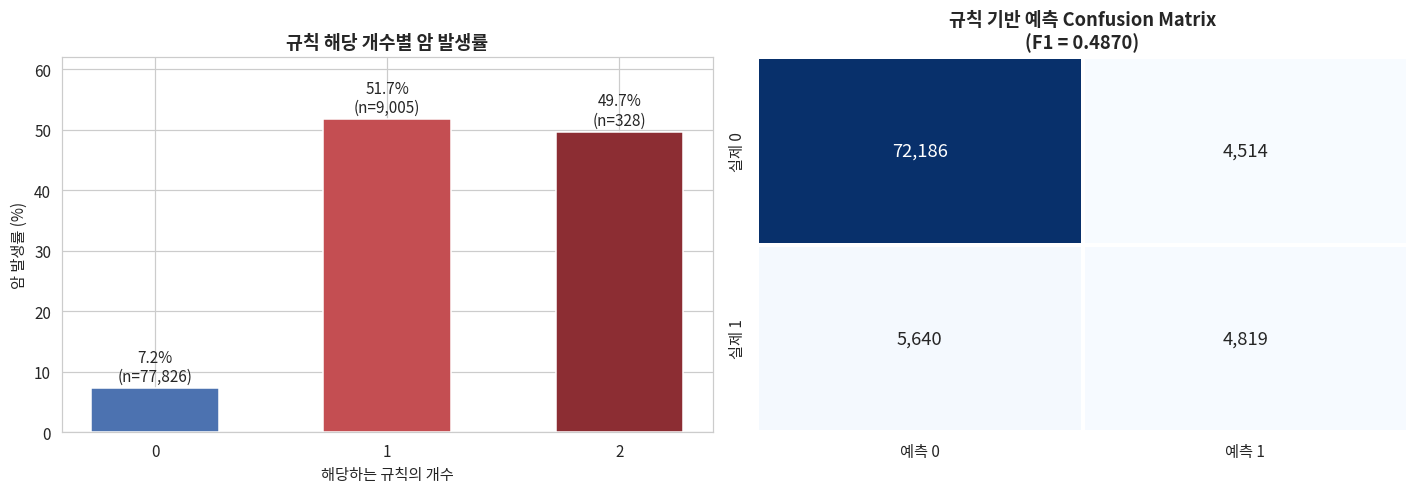

In [19]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

pred = (tr_r['n_rule'] >= 1).astype(int)
print('■ 규칙 3개만으로 예측했을 때 (학습 데이터 기준)')
print(f'  Accuracy  = {accuracy_score(train[TARGET], pred):.4f}')
print(f'  Precision = {precision_score(train[TARGET], pred):.4f}')
print(f'  Recall    = {recall_score(train[TARGET], pred):.4f}')
print(f'  F1-score  = {f1_score(train[TARGET], pred):.4f}')
print()
print('■ 비교: 모두 0으로 예측 → Accuracy = %.4f, F1 = 0.0000'
      % (1 - train[TARGET].mean()))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

g = tr_r.groupby('n_rule')[TARGET].agg(['mean', 'size'])
bars = axes[0].bar(g.index.astype(str), g['mean']*100,
                   color=['#4C72B0', '#C44E52', '#8C2D33'], width=0.55)
for b, v, n in zip(bars, g['mean'], g['size']):
    axes[0].text(b.get_x()+b.get_width()/2, v*100+1.2,
                 f'{v*100:.1f}%\n(n={n:,})', ha='center', fontsize=10)
axes[0].set_xlabel('해당하는 규칙의 개수')
axes[0].set_ylabel('암 발생률 (%)')
axes[0].set_ylim(0, 62)
axes[0].set_title('규칙 해당 개수별 암 발생률', fontsize=12, fontweight='bold')

cm = confusion_matrix(train[TARGET], pred)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', linewidths=1.5,
            xticklabels=['예측 0', '예측 1'], yticklabels=['실제 0', '실제 1'],
            ax=axes[1], annot_kws={'fontsize': 12}, cbar=False)
axes[1].set_title(f'규칙 기반 예측 Confusion Matrix\n(F1 = {f1_score(train[TARGET], pred):.4f})',
                  fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig10_rule_validation.png')
plt.show()

> 파생변수 3개, 하이퍼파라미터 0개, 학습 과정 없는 순수 규칙만으로 **F1 = 0.487**이 나온다.
> 반면 원본 변수를 그대로 넣은 선형 모델은 이 상호작용을 표현할 수 없어 훨씬 낮은 성능에 그친다.
> **2주차 Feature Engineering의 방향이 여기서 결정된다.**

In [20]:
# 규칙에 해당하지 않는 기저 그룹(n=77,826)에 잔여 신호가 남아 있는지 확인
print('■ 기저 그룹 내 변수별 최대 발생률 격차')
for c in CAT_COLS:
    g = base.groupby(c)[TARGET].mean()
    print(f'  {c:20s} {(g.max()-g.min())*100:5.2f}%p')
print(f'\n기저 그룹 암 발생률 : {base[TARGET].mean()*100:.2f}%  (n={len(base):,})')
print('→ 어떤 변수로도 7%대 기저 발생률을 더 쪼갤 수 없다.')
print('  즉 전체 양성의 약 53%는 설명 불가능한 잡음(irreducible noise)이며,')
print('  이는 달성 가능한 F1의 상한이 존재함을 의미한다.')

■ 기저 그룹 내 변수별 최대 발생률 격차
  Gender                0.27%p
  Country               1.37%p
  Race                  0.50%p
  Family_Background     0.30%p
  Radiation_History     0.09%p
  Iodine_Deficiency     0.08%p
  Smoke                 0.10%p
  Weight_Risk           0.23%p
  Diabetes              0.01%p

기저 그룹 암 발생률 : 7.25%  (n=77,826)
→ 어떤 변수로도 7%대 기저 발생률을 더 쪼갤 수 없다.
  즉 전체 양성의 약 53%는 설명 불가능한 잡음(irreducible noise)이며,
  이는 달성 가능한 F1의 상한이 존재함을 의미한다.


### (10) train / test 분포 일치 여부 확인

학습 데이터에서 얻은 통계량(스케일러, 인코딩 매핑 등)을 테스트 데이터에 그대로 적용해도
되는지 판단하기 위해, 두 데이터의 분포가 같은지 검정한다.

In [21]:
rows = []
for c in NUM_COLS:
    ks, p = stats.ks_2samp(train[c], test[c])
    rows.append({'변수': c, '검정': 'KS 검정', '통계량': ks, 'p-value': p,
                 'train 평균': train[c].mean(), 'test 평균': test[c].mean()})
for c in CAT_COLS:
    a = train[c].value_counts(normalize=True)
    b = test[c].value_counts(normalize=True)
    rows.append({'변수': c, '검정': '비율 최대차', '통계량': (a-b).abs().max(),
                 'p-value': np.nan, 'train 평균': np.nan, 'test 평균': np.nan})
shift = pd.DataFrame(rows)
print('※ p-value > 0.05 이면 두 분포가 다르다고 볼 근거가 없음')
shift.round(4)

※ p-value > 0.05 이면 두 분포가 다르다고 볼 근거가 없음


,변수,검정,통계량,p-value,train 평균,test 평균
0,Age,KS 검정,0.0032,0.9218,50.8602,50.9283
1,Nodule_Size,KS 검정,0.0063,0.1806,2.5081,2.4991
2,TSH_Result,KS 검정,0.0041,0.6980,5.0569,5.0641
3,T4_Result,KS 검정,0.0030,0.9514,8.2488,8.2467
4,T3_Result,KS 검정,0.0059,0.2387,2.0050,2.0124
5,Gender,비율 최대차,0.0006,NaN,NaN,NaN
6,Country,비율 최대차,0.0037,NaN,NaN,NaN
7,Race,비율 최대차,0.0103,NaN,NaN,NaN
8,Family_Background,비율 최대차,0.0075,NaN,NaN,NaN
9,Radiation_History,비율 최대차,0.0008,NaN,NaN,NaN


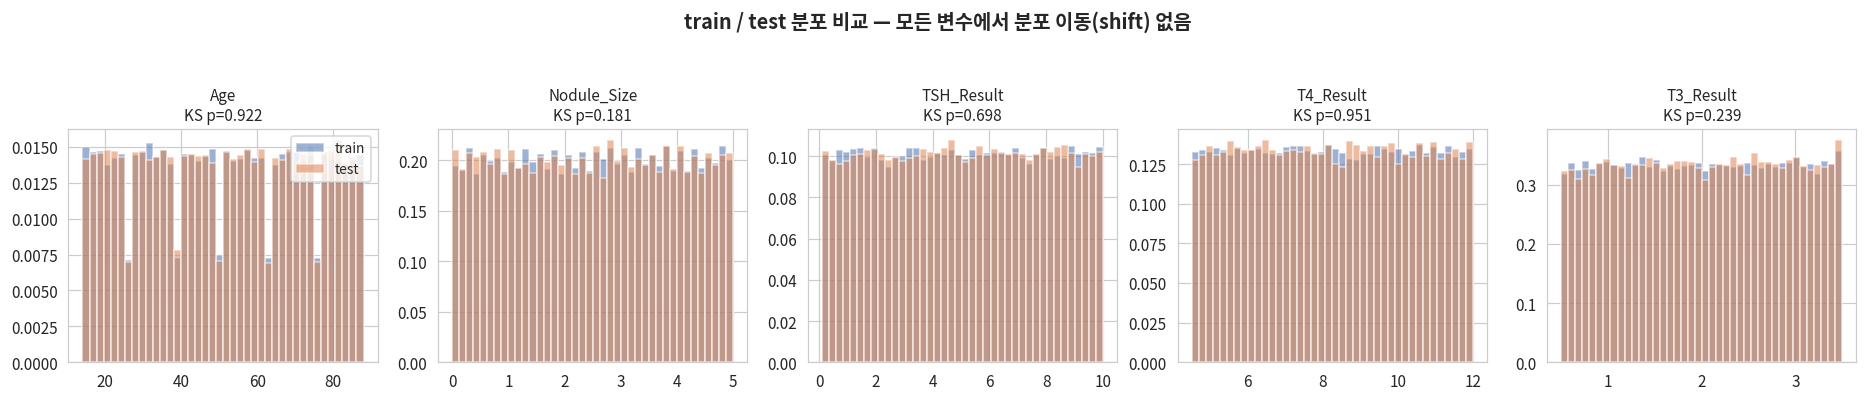

In [22]:
fig, axes = plt.subplots(1, 5, figsize=(17, 3.4))
for i, c in enumerate(NUM_COLS):
    axes[i].hist(train[c], bins=40, density=True, alpha=0.55,
                 color='#4C72B0', label='train')
    axes[i].hist(test[c], bins=40, density=True, alpha=0.55,
                 color='#DD8452', label='test')
    ks, p = stats.ks_2samp(train[c], test[c])
    axes[i].set_title(f'{c}\nKS p={p:.3f}', fontsize=10)
    if i == 0:
        axes[i].legend(fontsize=9)
plt.suptitle('train / test 분포 비교 — 모든 변수에서 분포 이동(shift) 없음',
             fontsize=13, fontweight='bold', y=1.06)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig11_train_test.png')
plt.show()

> 모든 수치형 변수의 KS 검정 p-value가 0.18을 넘고, 범주형 비율 차이도 최대 1%p 수준이다.
> **분포 이동이 없으므로 train 통계량을 test에 적용해도 안전하다.**

---
## 1-3. 분석 결과

EDA를 통해 발견한 이 데이터의 특징을 항목별로 정리한다.

### ① 데이터 불균형 — 존재함 (약 8:1)

| 클래스 | 건수 | 비율 |
|---|---|---|
| 0 (양성) | 76,700 | 88.00% |
| 1 (악성) | 10,459 | 12.00% |

전체를 0으로 찍기만 해도 Accuracy 88%가 나온다. 따라서 **Accuracy는 주지표로 부적합**하며
F1-score를 중심으로 Precision/Recall의 균형을 봐야 한다. 임계값(threshold) 조정,
`class_weight='balanced'`, 계층적 분할(stratified split)이 필수적으로 요구된다.

### ② 결측치 — 존재하지 않음

train 87,159행, test 46,204행 전체에서 결측치가 **0건**이다. 완전 중복 행도 없고 ID 중복도 없다.
2주차의 결측치 처리 항목은 실제 적용 대상이 없으므로, **인위적 결측 주입 실험**을 통해
방법론을 설명하는 방식으로 대체할 계획이다.

### ③ 이상치 — 존재하지 않음 (통계적으로도, 의학적으로도)

IQR 기준 이상치가 5개 수치형 변수 모두에서 0건이다. 이는 데이터가 깨끗해서가 아니라
**모든 변수가 유한 구간의 균등분포로 생성되었기 때문**이다.

| 변수 | 관측 범위 | 왜도 | 첨도 |
|---|---|---|---|
| Age | 14 ~ 88 | 0.006 | -1.199 |
| Nodule_Size | 0.00 ~ 5.00 | -0.007 | -1.197 |
| TSH_Result | 0.10 ~ 10.00 | -0.000 | -1.201 |
| T4_Result | 4.50 ~ 12.00 | 0.002 | -1.202 |
| T3_Result | 0.50 ~ 3.50 | -0.000 | -1.203 |

균등분포의 이론적 첨도는 정확히 -1.2이며, 관측값이 이와 소수점 두 자리까지 일치한다.
**따라서 이상치 제거·클리핑·로그변환은 모두 적용할 이유가 없다.**

### ④ 상관관계가 높은 변수 — 단변량으로는 없음, 조합에서는 매우 강함

**(a) 수치형 5개는 전부 무의미하다.**
타깃과의 상관계수 절댓값이 모두 0.01 미만이며(최대 |r| = 0.0082, TSH_Result),
변수 간 다중공선성도 없다(최대 |r| = 0.0062). 임상 상식과 달리 결절 크기나 호르몬 수치가
암 여부와 전혀 관련이 없다는 점은, 이 데이터가 합성 데이터라는 판단을 재확인시킨다.

**(b) 범주형 9개 중 4개도 완전한 잡음이다.**

| 변수 | p-value | 판정 |
|---|---|---|
| Gender | 0.861 | 신호 없음 |
| Smoke | 0.852 | 신호 없음 |
| Weight_Risk | 0.509 | 신호 없음 |
| Diabetes | 0.943 | 신호 없음 |

**(c) 진짜 구조는 3개의 상호작용에 있다. — 본 EDA의 핵심 발견**

| 조건 | 해당 건수 | 암 발생률 | 대조군 | 격차 |
|---|---|---|---|---|
| `Race=ASN` **AND** `Family_Background=Positive` | 4,631 | **51.3%** | ASN·Negative 9.0% | 42.3%p |
| `Race=AFR` **AND** `Radiation_History=Exposed` | 1,928 | **52.5%** | AFR·Unexposed 8.7% | 43.8%p |
| `Country=IND` **AND** `Iodine_Deficiency=Deficient` | 3,102 | **51.4%** | IND·Sufficient 10.7% | 40.7%p |
| 위 어느 것에도 해당하지 않음 | 77,826 | **7.25%** | — | — |

각 위험요인은 **특정 집단 안에서만** 작동한다. 예컨대 가족력은 ASN에서 42.3%p의 격차를 만들지만
AFR에서는 -1.1%p, CAU에서는 0.03%p로 아무 효과가 없다. 전체 평균으로 뭉개서 보면
가족력 효과가 7.7%p로 축소되어 보이는데, 이것이 심프슨의 역설이다.

**(d) 검증:** 위 3개 규칙만으로 예측하면 **F1 = 0.487**(Accuracy 0.884, Precision 0.516, Recall 0.461)이
나온다. 학습도 튜닝도 없는 규칙만으로 이 정도가 나온다는 것은, 이 데이터의 신호가
개별 변수가 아니라 **조합에 들어 있음**을 결정적으로 보여준다.

**(e) 성능 상한의 존재:** 규칙에 해당하지 않는 기저 그룹(77,826건, 전체의 89.3%)에서는
어떤 변수를 넣어도 발생률 격차가 최대 1.37%p에 불과하다. 이 그룹의 7.25%,
즉 전체 양성의 약 53%(5,640건)는 **어떤 모델로도 설명할 수 없는 잡음**이다.
따라서 3주차에서 F1이 0.5 부근에서 정체되더라도 그것은 모델의 실패가 아니라
데이터의 구조적 한계이며, 이 점을 미리 인지하고 평가해야 한다.

### ⑤ train / test 분포 — 완전히 일치

수치형 5개의 KS 검정 p-value가 모두 0.18 이상이고, 범주형 비율 차이도 최대 1.03%p다.
분포 이동이 없으므로 train에서 학습한 전처리 파라미터를 test에 그대로 적용해도 무방하다.

### ⑥ 전처리가 필요한 컬럼 요약

| 구분 | 컬럼 | 필요한 처리 |
|---|---|---|
| 반드시 필요 | 범주형 9개 | 인코딩 (모델이 문자열을 못 받음) |
| 반드시 필요 | Race, Country, Family_Background, Radiation_History, Iodine_Deficiency | **상호작용 파생변수 생성** |
| 조건부 필요 | 수치형 5개 | 거리/경사 기반 모델 사용 시에만 스케일링 |
| 제거 후보 | Gender, Smoke, Weight_Risk, Diabetes | 신호 없음 — 제거 여부를 실험으로 결정 |
| 제거 | ID | 식별자 |
| 불필요 | 전 컬럼 | 결측치 처리, 이상치 처리 (대상 없음) |


---
## 1-4. 전처리 계획

2주차에 수행할 전처리를 **무엇을 / 어떻게 / 왜**의 형태로 정리한다.

### 계획 1. 결측치 처리 — 적용 대상 없음, 방법론은 실험으로 검증

- **대상:** 없음 (train/test 모두 결측 0건)
- **방법:** 실제 처리 대신, 임의로 결측을 주입한 사본을 만들어
  ① 단순 삭제 ② 평균/중앙값 대치 ③ 최빈값 대치 ④ 결측 자체를 하나의 범주로 처리
  네 가지를 비교하고 성능 영향을 측정한다.
- **이유:** 처리할 결측이 없다고 해서 항목을 생략하면 과제 요구사항을 충족하지 못한다.
  통제된 실험으로 각 기법의 특성을 보이는 편이 형식적 설명보다 낫다.
  특히 이 데이터는 균등분포이므로 **평균 대치가 분포를 왜곡하는 정도**를 시각적으로 보여주기에 적합하다.

### 계획 2. 이상치 처리 — 적용하지 않음 (근거 제시)

- **대상:** 없음
- **방법:** IQR·Z-score·백분위 클리핑 세 기준으로 재확인한 뒤, **처리하지 않는다**는 결론을 명시한다.
- **이유:** 모든 변수가 유한 구간 균등분포(첨도 ≈ -1.2)라 정의상 꼬리가 없다.
  기계적으로 상하위 1%를 자르면 **정보만 잃고 얻는 것이 없다.**
  "적용하지 않기로 결정했다"는 것도 근거가 있다면 유효한 전처리 결정이다.

### 계획 3. 인코딩 — 변수별로 다르게 적용

| 대상 | 방법 | 이유 |
|---|---|---|
| 이진 범주 6개<br>(Gender, Family_Background, Radiation_History, Iodine_Deficiency, Smoke, Weight_Risk, Diabetes) | **Binary(0/1) 매핑** | 수준이 2개뿐이라 One-Hot을 써도 열만 늘어날 뿐 정보가 같다 |
| `Race` (5수준) | **One-Hot** | 순서가 없는 명목형. 수준이 적어 차원 증가 부담이 없다 |
| `Country` (10수준) | **One-Hot + `is_IND` 별도 플래그** | IND만 특별한 역할을 하므로 명시적 플래그를 추가한다 |

- **Label Encoding을 쓰지 않는 이유:** ASN=0, AFR=1, CAU=2 식으로 부여하면 존재하지 않는
  순서 관계를 모델에 주입하게 된다. 트리 모델은 견디지만 선형 모델에서는 해석이 무너진다.
- **Target Encoding을 1순위로 쓰지 않는 이유:** 타깃 정보를 특징에 넣는 방식이라
  데이터 누수(leakage) 위험이 있다. 사용한다면 Out-of-Fold 방식으로 제한하고, 3주차에 비교한다.

### 계획 4. Scaling — 모델에 따라 조건부 적용

- **대상:** Age, Nodule_Size, TSH_Result, T4_Result, T3_Result
- **방법:** `MinMaxScaler`를 기본으로 하고, `StandardScaler`와 성능을 비교한다.
  트리 계열(Random Forest, XGBoost, LightGBM)에는 **적용하지 않는다.**
- **이유:**
  - 다섯 변수의 범위가 0~5, 0.1~10, 4.5~12, 14~88로 제각각이라
    거리 기반(KNN)·경사하강 기반(Logistic Regression, SVM) 모델에서는 스케일이 큰 `Age`가
    거리 계산을 지배한다.
  - **`MinMaxScaler`를 선택한 근거:** 이 변수들은 정규분포가 아니라 **균등분포**다.
    평균 0·표준편차 1로 맞추는 `StandardScaler`는 정규성을 가정할 때 의미가 크지만,
    상하한이 명확한 균등분포에서는 [0,1] 구간으로 선형 사상하는 MinMax가 원래 형태를 그대로 보존한다.
    또한 이상치가 없으므로 MinMax의 최대 약점(극단값 민감성)이 문제되지 않는다.
  - 트리 모델은 분할 기준이 값의 크기가 아닌 순서에 의존하므로 스케일링이 성능에 무관하다.

### 계획 5. Feature Engineering — 본 과제의 핵심

EDA에서 발견한 상호작용 구조를 명시적 변수로 만든다. **이것이 성능을 좌우한다.**

**(a) 상호작용 플래그 3개 — 1순위**
```python
df['ASN_Family']   = (df.Race == 'ASN')    & (df.Family_Background == 'Positive')
df['AFR_Radiation']= (df.Race == 'AFR')    & (df.Radiation_History == 'Exposed')
df['IND_Iodine']   = (df.Country == 'IND') & (df.Iodine_Deficiency == 'Deficient')
```
- **이유:** 이 세 변수만으로 F1 0.487이 나온다는 것을 1-2절 (9)에서 확인했다.
  선형 모델은 원본 변수만으로는 이 구조를 절대 표현할 수 없고,
  트리 모델도 깊이가 충분해야 스스로 찾아낸다. 명시적으로 주면 학습이 훨씬 쉬워진다.

**(b) 위험요인 개수 집계**
```python
df['n_risk'] = ASN_Family + AFR_Radiation + IND_Iodine
```
- **이유:** 규칙 해당 개수(0/1/2)에 따라 발생률이 7.3% → 51.7% → 49.7%로 계단식으로 변한다.
  순서형 변수로 압축하면 트리 모델이 단일 분할로 큰 이득을 얻는다.

**(c) 위험군 여부 이진 플래그**
```python
df['is_high_risk'] = (df.n_risk >= 1)
```

**(d) 검증할 가설 — 저신호 변수 제거**
- `Gender`, `Smoke`, `Weight_Risk`, `Diabetes` 4개를 제거한 버전과 유지한 버전을 각각 학습해
  성능을 비교한다.
- **이유:** p-value가 0.5~0.94로 신호가 전혀 없어 트리 모델에서 무의미한 분할을 유발할 수 있다.
  다만 "약한 신호"와 "잡음"을 사전에 단정하기보다 **실험으로 확인**하는 것이 안전하다.

**(e) 시도하되 기대는 낮게 — 수치형 파생**
- `T3/T4` 비율, `TSH×Nodule_Size`, `Age` 구간화 등을 만들어 본다.
- **이유:** 원 변수의 신호가 |r| < 0.01이므로 성공 가능성은 낮다. 다만 임상적으로 T3/T4 비율은
  갑상선 기능 평가에 쓰이는 지표이므로, 데이터 생성 과정에 반영되었을 가능성을 배제하지 않고
  한 번은 검증한다.

### 계획 6. 데이터 분할 전략 (3주차 대비)

- **방법:** `train_test_split(..., stratify=y, test_size=0.2, random_state=42)`
  및 `StratifiedKFold(n_splits=5)` 교차검증
- **이유:** 양성 비율이 12%이므로 무작위 분할 시 폴드별 양성 비율이 흔들려 평가가 불안정해진다.
  계층적 분할로 각 폴드의 클래스 비율을 12%로 고정해야 한다.

### 전처리 계획 요약표

| # | 항목 | 대상 | 방법 | 우선순위 |
|---|---|---|---|---|
| 1 | 결측치 | 없음 | 인위적 주입 후 기법 비교 | 낮음 |
| 2 | 이상치 | 없음 | 미적용 (근거 제시) | 낮음 |
| 3 | 인코딩 | 범주형 9개 | Binary + One-Hot | **필수** |
| 4 | Scaling | 수치형 5개 | MinMax (트리 모델 제외) | 중간 |
| 5 | Feature Eng. | 상호작용 | 플래그 3개 + 개수 집계 | **최우선** |
| 6 | 컬럼 제거 | ID / 저신호 4개 | ID 제거, 나머지는 실험 후 결정 | 중간 |
| 7 | 분할 | 전체 | Stratified 5-Fold | **필수** |


---
## 마무리

이번 EDA의 가장 중요한 결론은, **개별 변수의 상관계수만 보고 "쓸 만한 변수가 없다"고
판단했다면 이 데이터의 실제 구조를 완전히 놓쳤을 것**이라는 점이다.

Cramér's V 최댓값 0.126, 수치형 상관계수 절댓값 0.01 미만이라는 수치는 데이터에 신호가
거의 없다는 인상을 준다. 그러나 변수를 조합하자 40%p가 넘는 격차를 가진 세 개의 규칙이
드러났고, 이 규칙만으로 F1 0.487을 얻었다.

동시에, 규칙으로 설명되지 않는 기저 그룹에는 어떤 잔여 신호도 남아 있지 않다는 점도 확인했다.
전체 양성의 약 53%는 구조적으로 예측 불가능하다. 이는 3주차에서 달성 가능한 성능에
명확한 상한이 있음을 뜻하며, 무리한 튜닝으로 이 벽을 넘으려 하기보다 **상호작용 특징을
제대로 만들어 상한에 최대한 근접시키는 것**이 올바른 전략임을 시사한다.

---

## 참고 문헌

1. Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley.
2. Anscombe, F. J. (1973). "Graphs in Statistical Analysis." *The American Statistician*, 27(1), 17–21.
   https://www.jstor.org/stable/2682899
3. Matejka, J., & Fitzmaurice, G. (2017). "Same Stats, Different Graphs: Generating Datasets with
   Varied Appearance and Identical Statistics through Simulated Annealing." *CHI 2017*.
   https://www.research.autodesk.com/publications/same-stats-different-graphs/
4. DACON. "갑상선암 진단 분류 해커톤 : 양성과 악성, AI로 정확히 구분하라!"
   https://dacon.io/competitions/official/236488/overview/description
5. Wikipedia. "Simpson's paradox." https://en.wikipedia.org/wiki/Simpson%27s_paradox
6. Cramér, H. (1946). *Mathematical Methods of Statistics*. Princeton University Press. (Cramér's V)
7. scikit-learn developers. "Preprocessing data — scikit-learn User Guide."
   https://scikit-learn.org/stable/modules/preprocessing.html
8. seaborn developers. "seaborn: statistical data visualization." https://seaborn.pydata.org/
9. Massey, F. J. (1951). "The Kolmogorov-Smirnov Test for Goodness of Fit."
   *Journal of the American Statistical Association*, 46(253), 68–78.
10. He, H., & Garcia, E. A. (2009). "Learning from Imbalanced Data."
    *IEEE Transactions on Knowledge and Data Engineering*, 21(9), 1263–1284.
